# Reduce a DFXM rocking scan measured at ESRF ID03

A **mu x chi mesh** rock (both angles swept together over one plane of the objective's own
`obpitch` angle), the geometry of the Mg-4Al g9 campaign this reader was built against.

**Why Part B before Part C.** Part C (below) reduces the real result: all 8 `obpitch` planes,
combined into orientation and strain maps, live from raw frames. It loads each plane in a loop
and does **not** re-derive every check from scratch -- in particular, it calls
`check_frame_order` on each plane exactly because Part B is where you first meet that check, on
one plane, small enough to read the output and understand what CONSISTENT does and does not
mean. Skip Part B and you'd be trusting all 8 planes' frame/angle pairing on faith in Part C.

`reduce_rocking` (Part B) is the general-purpose tool for any rocking scan you measure, one
plane / one curve per pixel at a time. Part C uses a different method: the campaign's own
joint-moment reduction, combining all 8 planes into a strain axis, which `reduce_rocking` does
not do. Learn the tool here; see it deployed for real in Part C.

**Steps:** set `H5_PATH` and `PLANE` in B1, run **B0** to see what is in the frame, then run
everything from B1. With no `H5_PATH`, everything runs on `dx.example_rocking_scan("mesh")`, a
synthetic two-axis rock with a known answer, so the notebook works with no download.

### B0. What does this plane look like?

Reads a subsample of frames from one plane and shows their maximum minus their median, to
find the grain before loading everything. The workshop subset (`umich_school_subset.h5`) is
already cropped to a 256 x 256 region inside the grain, so this is mostly a sanity check here --
**on the full campaign file** (2048 x 2048, ~2.7 GB per plane) it is required: B1 refuses to
load a real plane with `ROI=None`, for that memory reason.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import midas_dfxm as dx
from midas_dfxm.io_id03 import list_id03_planes

H5_PATH   = None   # e.g. "umich_school_subset.h5" (workshop subset, planes 4 and 5) or the
                    # full campaign master .h5
PLANE     = 5       # which obpitch plane (scan entry "<PLANE>.1") to reduce
ROI_GUESS = None    # optional (row0, row1, col0, col1) to draw on the picture

if H5_PATH and os.path.isfile(H5_PATH):
    print("planes in this file:", list_id03_planes(H5_PATH))
    import h5py
    import hdf5plugin
    with h5py.File(H5_PATH, "r") as f:
        img = f[f"{PLANE}.1/instrument/pco_ff/image"]
        M = img.shape[0]
        picks = range(0, M, max(M // 15, 1))
        stack = np.stack([img[i] for i in picks]).astype(np.float32)
    frame = stack.max(0) - np.median(stack, 0)
    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    im = ax.imshow(frame, cmap="magma", vmin=0, vmax=np.percentile(frame, 99.8))
    if ROI_GUESS:
        r0, r1, c0, c1 = ROI_GUESS
        ax.add_patch(plt.Rectangle((c0, r0), c1 - c0, r1 - r0, fill=False, color="cyan", lw=1.5))
    ax.set_title(f"plane {PLANE}.1: max - median over {len(picks)} frames", fontsize=10)
    ax.set_xlabel("column"); ax.set_ylabel("row"); ax.grid(True, alpha=0.3)
    plt.colorbar(im, ax=ax, fraction=0.046); plt.show()
else:
    print("No H5_PATH: skip B0. B1 will run on a synthetic mesh scan with a known answer.")

No H5_PATH: skip B0. B1 will run on a synthetic mesh scan with a known answer.


## Part B -- reduce a scan you measured (ESRF ID03)

This runs on **real detector frames**, with `load_id03_scan`, `check_frame_order`,
`reduce_rocking` and `baseline_sensitivity` -- tested against a planted answer
(`tests/test_io_id03.py`), not code that lives only in this notebook.

**You need** the campaign's master HDF5 file and a plane number:

| what | where |
|---|---|
| workshop practice data | `umich_school_subset.h5` (planes 4 and 5, already cropped to the grain) |
| your own campaign | the master `.h5` written at the beamline (one file, Bliss/Nexus layout, entries `"<plane>.1"`) |

**Picking a plane.** `obpitch` (the objective's own angle) is fixed within one plane and is
*not* one of the angles `reduce_rocking` fits -- load one plane to get one `tilt2d` (mu, chi)
map. `list_id03_planes(H5_PATH)` (run in B0) lists what is in the file. In this campaign, planes
4-6 carry nearly all the diffracted signal; the workshop subset ships 4 and 5.

- **Darks.** No per-scan dark convention at ID03 in this campaign: leave `DARK = None`: the
  per-pixel baseline in `reduce_rocking` absorbs the pedestal, which carries 90-98 % of the
  recorded counts here.
- **`hdf5plugin`.** The image dataset is compressed with a filter only `hdf5plugin` registers.
  If loading fails with an opaque low-level HDF5 error rather than a clear message, check that
  `hdf5plugin` (not just `h5py`) is installed in this environment.
- **Memory.** One full-frame plane is `(650, 2048, 2048)` uint16, ~2.7 GB; the 256 x 256
  workshop subset is ~170 MB as float32. Set `ROI` on the full campaign file the same way B0
  does above.

**No `H5_PATH` at all?** Part B then runs on `dx.example_rocking_scan("mesh")`, a synthetic
two-axis (theta-like, chi-like) rock with a known per-axis answer, so every cell below shows
output and the lesson works without a download.

Five steps, each with a check that can come back the other way:
**B1** load and read the survey · **B2** is every frame paired with its own angle? ·
**B3** reduce: pedestal, centre, width, error bar · **B4** how much does the baseline choice
matter? · **B5** what the map can and cannot tell you.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import midas_dfxm as dx

# ---- the only lines you change -----------------------------------------------------
H5_PATH = H5_PATH if "H5_PATH" in dir() and H5_PATH else None   # set in B0, or here
PLANE   = PLANE if "PLANE" in dir() and PLANE else 5
ROI     = None   # (row0, row1, col0, col1); only needed cropping further than the workshop subset
DARK    = None   # a number or a 2-D array, same exposure as the scan; usually None at ID03
GAIN    = None   # electrons per count if the detector record gives it; None = unknown
# -------------------------------------------------------------------------------------

HAVE_SCAN = bool(H5_PATH) and os.path.isfile(H5_PATH)
if HAVE_SCAN:
    scan = dx.load_id03_scan(H5_PATH, plane=PLANE, roi=ROI, dark=DARK)
else:
    # No scan yet: a synthetic two-axis rock with a known per-axis answer.
    scan = dx.example_rocking_scan("mesh", n_repeats=1, seed=0)
    print("No H5_PATH set: using dx.example_rocking_scan('mesh'), a synthetic scan with a known answer.\n")
print(scan.summary())

No H5_PATH set: using dx.example_rocking_scan('mesh'), a synthetic scan with a known answer.

source      example_rocking_scan('mesh')
frames      400 points x 64 x 64 px, 1 repeat(s) averaged per point
scan type   tilt2d (rocking coordinate: th, chi)
moves       th: 7.3000 .. 7.3190 deg, step 1.000 mdeg
moves       chi: 0.0000 .. 0.0190 deg, step 1.000 mdeg
split-half  angle parity


### B2. Is every frame paired with its own angle?

Do this before looking at any map. A stack whose frames are paired with the wrong angles still
produces a smooth, plausible map — no error, no warning. `check_frame_order` compares how alike
neighbouring frames are with the same score for random orderings of the same frames and, when
the scan has repeats, how closely two repeats of one point agree.

**CONSISTENT** is required before going on. **NOT CONFIRMED** means find out why — the file
order, the wrong motor table, repeats read in the wrong order — or the scan has no contrast to
test with.

**What CONSISTENT does not tell you.** It rules out a random or badly scrambled pairing, and
nothing more. A reversed sweep (every tilt changes sign), a table with the right number of rows
but the wrong step (every tilt scales), a constant angle offset, repeat-major frames read point-major, or any
other *smooth* wrong
order passes with the same score. `load_id03_scan` guards the file side -- refuses a
bad plane, a mismatched mu/chi length, a missing dataset -- but the motor values recorded in
the file itself you have to trust; there is no repeat structure here to cross-check against
(this campaign records one frame per mu/chi point, not several).

Look at the rocking curve too: one peak, inside the scanned range, not cut off at either end.

**Try it.** Before running the cell below, predict: if the frames were paired with a
*scrambled* order (e.g. read in file order instead of acquisition order), would the printed
p-value look different from a correctly-ordered scan? Would the rocking curve plotted below
still look smooth? Write your prediction down, then run the cell and check -- then try
actually scrambling `scan.motors["mu"]` (e.g. `np.random.default_rng(0).permutation(...)`) on
a copy and re-running `check_frame_order` on it, to see for yourself instead of taking the
text above on faith.

frame order CONSISTENT: adjacent-frame correlation 0.066 vs random orders median -0.001, p99 0.009 (p = 0.00498) [215 px, 200 permutations, smallest possible p 0.00498]. This rules out a scrambled pairing, not a reversed sweep or a wrong step or offset in the motor table.


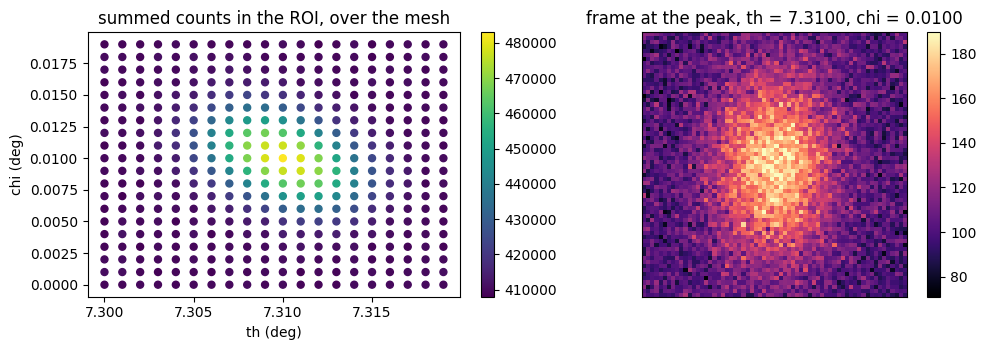

In [3]:
order_check = dx.check_frame_order(scan)
print(order_check)
x = scan.coordinate
curve = scan.frames.reshape(len(x), -1).sum(1)
k = int(np.argmax(curve))
mesh = scan.scan_type == "tilt2d"
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
if mesh:
    sca = ax[0].scatter(x[:, 0], x[:, 1], c=curve, cmap="viridis", s=25)
    ax[0].set_xlabel(f"{scan.axes[0]} (deg)"); ax[0].set_ylabel(f"{scan.axes[1]} (deg)")
    ax[0].set_title("summed counts in the ROI, over the mesh"); plt.colorbar(sca, ax=ax[0], fraction=0.046)
    peak_where = f"{scan.axes[0]} = {x[k, 0]:.4f}, {scan.axes[1]} = {x[k, 1]:.4f}"
else:
    ax[0].plot(x, curve, "o-", ms=3)
    ax[0].set_xlabel(f"{scan.axes[0]}{' / 2' if scan.scan_type == 'strain' else ''} (deg)")
    ax[0].set_ylabel("summed counts in the ROI"); ax[0].set_title("rocking curve of the ROI")
    peak_where = f"{scan.axes[0]} = {x[k]:.4f}"
im = ax[1].imshow(scan.frames[k], cmap="magma", vmax=np.percentile(scan.frames[k], 99.5))
ax[1].set_title(f"frame at the peak, {peak_where}")
plt.colorbar(im, ax=ax[1], fraction=0.046); ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()


### B3. Reduce: pedestal, centre, width, error bar

On these detectors the **pedestal** (dark level plus diffuse background) carries most of the
recorded counts — the summary prints the share. A first moment taken on raw frames is pulled
toward the middle of the scan, so tilts come out many times too small while the map still looks
smooth. `reduce_rocking` therefore works pixel by pixel:

1. find the pixel's peak and measure its baseline on the frames **outside** the peak;
2. subtract it and take the centre (first moment) **inside** the peak;
3. take the width from the half-maximum crossings (instrument included);
4. repeat the centre on two independent halves of the data — two sets of repeats if the scan
   has them, otherwise even and odd frames — for an **error bar** that needs no noise model.

A pixel is **lit** when its integrated intensity is at least 10× its own noise, measured off
the peak; a few background pixels (about 0.1–0.2 % of pure noise) still pass by chance.
**Truncated** means the pixel's peak *window* (±2 widths) reaches an end of the scan: a peak cut
off by the scan range, but also a very wide or double-peaked pixel. Its centre may be biased, and
the summary leaves it out.

The map is a tilt in mdeg — or, for a θ–2θ scan, a relative d-spacing change in microstrain —
**relative to the median of the lit pixels**, in detector rows and columns.

This is the standard reduction, and it assumes **one peak per pixel** -- over the mu x chi
mesh here, not a 1-D curve. There is no curve-shape diagnostic for a 2-D mesh in this package,
so that assumption is not independently checked for a tilt2d scan; read `maps.single_peaked` as
`None` and the summary's `shape` line as "not computed" rather than "passed."


tilt2d map: 4096 lit px (100.0% of the ROI); 52 of them have their peak window at a scan edge (centre may be biased; left out below)
value[th] median 0 mdeg, IQR [-0.39, 0.379], p2-p98 [-0.975, 0.95] (relative to the reference; first moment in the peak window)
value[chi] median 0 mdeg, IQR [-0.331, 0.331], p2-p98 [-0.897, 0.896] (relative to the reference; first moment in the peak window)
reference   th=7.30961, chi=0.00960 deg (median centre, lit pixels)
pedestal    0.922 of the recorded counts in lit pixels was baseline -> a raw first moment would be diluted ~13x
settings    baseline=outside_peak, baseline_percentile=25.0, peak_halfwidth=2.0, window=peak, lit=auto (SNR >= 10, noise measured off-peak)


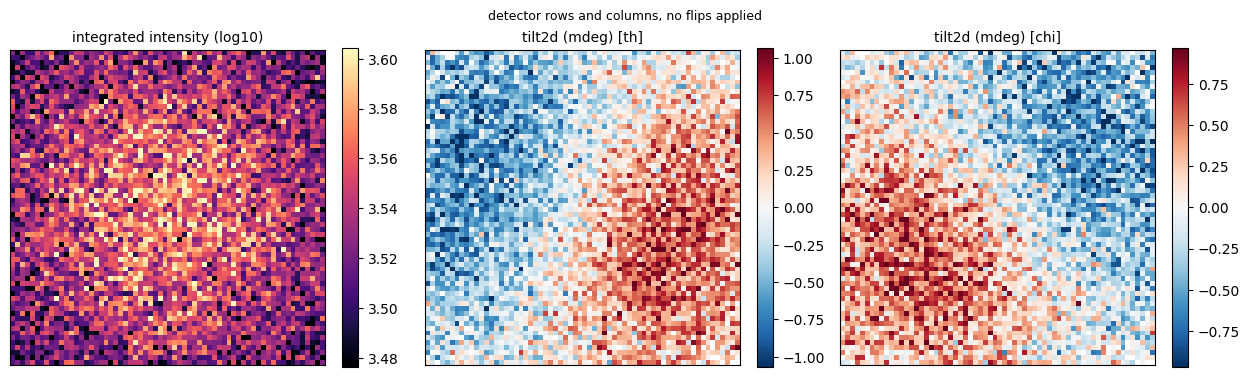

In [4]:
maps = dx.reduce_rocking(scan, gain=GAIN)
print(maps.summary())
show = maps.lit & ~maps.truncated

def expand(a, title, cmap, symmetric):
    """One panel for a (H, W) map, or one panel per axis for a (H, W, 2) mesh map."""
    if a is None:
        return []
    if a.ndim == 2:
        return [(np.where(show, a, np.nan), title, cmap, symmetric)]
    return [(np.where(show, a[..., i], np.nan), f"{title} [{maps.axes[i]}]", cmap, symmetric)
            for i in range(a.shape[-1])]

panels = [(np.log10(np.clip(maps.intensity, 1, None)), "integrated intensity (log10)", "magma", False)]
panels += expand(maps.value, f"{maps.scan_type} ({maps.unit})", "RdBu_r", True)
panels += expand(maps.fwhm_mdeg, "width, FWHM (mdeg)", "viridis", False)
panels += expand(maps.sigma, f"error bar ({maps.unit})", "cividis", False)
fig, ax = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 3.8))
ax = np.atleast_1d(ax)
for a, (img, title, cmap, symmetric) in zip(ax, panels):
    if symmetric:
        lim = np.nanpercentile(np.abs(img), 98)
        im = a.imshow(img, cmap=cmap, vmin=-lim, vmax=lim)
    else:
        im = a.imshow(img, cmap=cmap, vmin=np.nanpercentile(img, 2), vmax=np.nanpercentile(img, 98))
    a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
    plt.colorbar(im, ax=a, fraction=0.046)
plt.suptitle("detector rows and columns, no flips applied", fontsize=9)
plt.tight_layout(); plt.show()

# A tilt2d mesh has only one definition of "the centre" -- use this reduction directly.
WINDOW = "peak"
best = maps


### B4. How much does the map depend on the baseline choice?

The baseline is a choice, and defensible choices differ. `baseline_sensitivity` redoes the map
with each alternative (for `window="fixed"`: the signal window 3 frames wider and narrower,
and two percentile baselines) and compares them on 8×8-pixel blocks, where noise averages out. **Block
RMS** is how far the map moves: quote it beside the error bar, not the variant that looks best.
A **block slope** far from 1 means the choice rescales every tilt. The per-pixel spread also
contains noise, so it is only an upper bound on the systematic.

**On this small single-plane crop, expect it to look boring** (block RMS near 0.000 mdeg for
most variants): a small, mostly-uniform ROI has little room for a baseline choice to matter.
That is a real, correct result, not a broken check -- it means baseline choice is not the
dominant systematic *here*. Part C's grain-mask and band-slope checks (C5) play the analogous
role for the full 8-plane analysis, where there is more to find.


In [5]:
for row in dx.baseline_sensitivity(scan, window=WINDOW):
    print(f"{str(row['variant']):58s} block RMS {row['block_rms']:6.3f} {row['unit']}, "
          f"block slope {row['block_slope']:.3f}, per-pixel spread {row['pixel_spread']:.2f} "
          f"({row['n_blocks']} blocks)")


{'baseline': 'outside_peak', 'peak_halfwidth': 1.5}        block RMS  0.000 mdeg, block slope 1.000, per-pixel spread 0.00 (44 blocks)
{'baseline': 'outside_peak', 'peak_halfwidth': 3.0}        block RMS  0.000 mdeg, block slope 1.000, per-pixel spread 0.00 (44 blocks)
{'baseline': 'percentile', 'baseline_percentile': 25.0}    block RMS  0.000 mdeg, block slope 1.000, per-pixel spread 0.00 (44 blocks)
{'baseline': 'percentile', 'baseline_percentile': 50.0}    block RMS  0.338 mdeg, block slope 1.575, per-pixel spread 0.19 (44 blocks)


### B5. What this map can and cannot tell you

- **Relative, not absolute.** Tilts are measured from the median of the lit pixels. One scan
  gives no absolute orientation and no absolute strain zero.
- **One component.** A θ rock senses tilt about the rocking axis only; tilt about the other
  axis is nearly invisible (§1). A full orientation needs a second, orthogonal rock (§5–6).
- **One reflection gives Δd/d, not elastic strain.** In a solid solution a change of
  composition moves d just as strain does; the strain *tensor* needs several non-coplanar
  reflections.
- **The error bar is the scatter between two halves of the data, for these settings.** It
  leaves out the baseline choice (B4) and anything the two halves share: angle errors at each
  point, flux changes between points, drift, vibration. It also depends on the window. (This
  campaign has a flux-monitor channel, `pico4` -- our own check found it doesn't behave like a
  clean flux signal, so don't assume normalising by it fixes this; confirm on your own data.)
  This campaign has one frame per mu/chi point, so the split is even/odd frames and carries
  sampling error; it says nothing about repeat-to-repeat drift because there are no repeats.
- **Coarse sampling.** With only 2–3 points above half maximum, widths are quantized by the
  step — stripes in the width map follow where each peak falls on the angle grid — and the
  centre is less certain than a photon-only error bar says.
- **A background that rises and falls with the rocking curve** (a halo around the grain, or
  weak diffraction below the lit cut) survives the per-pixel baseline and pulls tilts toward
  zero, by roughly one to two times its height as a fraction of the peak (planted scans). It is
  not in the error bar.
- **A centre is one number for a whole curve, or a whole mesh.** If a pixel's true signal is
  more than one orientation (a sub-grain boundary crossing it, say), the centre-of-mass still
  reports a single number -- the intensity-weighted average, not "the" orientation -- and
  nothing in this reduction flags it: there is no curve-shape diagnostic for a mesh. Separating
  orientations inside one pixel needs many more points across each feature, and sometimes
  another scan.
- **The width includes the instrument.** Deconvolve a near-perfect crystal's width (§6) before
  calling it mosaic spread.
- **Lengths need the optics record.** µm per pixel is not in the motor table; take it from the
  objective's magnification record, not from a constant in someone's script.
- **Image orientation.** The maps are in detector rows and columns; relating them to the
  sample needs a fiducial (§1b, §7).


In [6]:
if HAVE_SCAN:
    out = "my_rocking_maps.npz"
    best.save(out)
    print("saved", os.path.abspath(out), f"-- every map from window={WINDOW!r}, the masks, and the settings used")
else:
    print("synthetic example: nothing saved")


synthetic example: nothing saved


## Bonus: the row-gradient story -- what nearly got reported as real

This is the same grain (Mg-4Al g9) and the same campaign as `umich_school_subset.h5`. Before
this workshop existed, an independent reduction that combined **all 8** `obpitch` planes (not
just the one you just reduced) built a per-pixel elastic-strain map -- and found a large,
smooth-looking gradient along the detector **row** axis. It went through four rounds of
adversarial testing (`/verify`, this group's standard practice before trusting a result). Three
different claims about it died; here is what survived, and why it matters for the map you just
built in B3.

**Round 1 -- "this is real elastic strain."** REFUTED. The row-band means ran
**+791, +390, +71, -69, -187 µe** across the field (std 401 µe), and 14.6 % of pixels sat above
+500 µe forming what looked like a coherent domain. Killed by physics: the CRL objective's
own field-of-view term predicts a **parameter-free** apparent gradient of 2.22 µe/row from
numbers already in the file (pixel size, magnification, `ffz`, `obx` -- no fit). Measured
-2.10 µe/row: 5 % off, right sign. Removing it dropped the strain std to 270 µe (54.7 % of the
variance was this one ramp) -- so whatever the "real" strain map was, it was not the raw one.

**Round 2 -- "and that gradient *is* the CRL field-of-view term."** ALSO REFUTED, on closer
testing:
- the FOV term must be identical at every column; the measured slope instead varies
  **0.9-1.2x the whole predicted term** across column bands, and changes sign in one reduction;
- it must be exactly linear; the data is **33 % non-linear** (quadratic R² 0.93-0.94 vs 0.83-0.84
  linear), and both independent reductions agree on the curvature to 0.3 % while disagreeing on
  the slope by 7 %;
- a parameter-free ratio test (predicted 1.0101) measured **1.28-1.41**, 26-40 % off;
- the "second independent reduction" that confirmed it was checked against a length range that
  had been **back-solved from the same measured slope** -- circular by construction;
- a purely geometric term cannot depend on pixel brightness; this one does (bright pixels
  steeper by -0.40 +/- 0.16 ue/row, t = -2.6).

**Round 3 -- the µ (orientation) map's own row structure, read as a "70-96 mdeg lattice
rotation."** REFUTED 4/4 too: it is not a ramp but a **saddle** -- the row slope flips sign
across column quartiles in both reductions on every mask tried (e.g. +0.47, +0.46, -0.12, -0.01
mdeg/px), and it does not clear its own zero-gradient null (p = 0.08-0.50, when the strain
ramp's identical test gave p < 0.00125). What *is* indicated: the µ centroid anticorrelates with
the local rocking-curve width across rows (corr -0.46/-0.49) -- a lattice rotation has no reason
to do that, an illumination-geometry effect would.

**What is actually established:** the row-aligned gradient is real and not a code bug (an
independent from-scratch reduction of the raw frames gives -2.108 ue/row against -2.101; 800
phase-randomised surrogates with no imposed gradient never reach it, p < 0.00125). What it
**is** -- an optical artifact, a real sample field, or some mix -- is not determined in this
dataset, for a specific and checkable reason.

**The reason: an identifiability limit, not more noise.** `samx/samy/samz` never move anywhere
in this campaign (`uz` is constant across all 8 planes despite the folder name
`layers_uz15um`). Detector row is also the beam-propagation axis. So a detector-frame optical
term and a real sample-frame gradient along rows are **mathematically indistinguishable** here
-- no amount of better statistics on this data separates them. The one measurement that would:
translate the sample along the imaged axis and re-measure. A detector-frame term stays fixed on
the detector; a sample-frame field moves with the sample.

Full write-up with every check and number: `RETRACTION_strain.md`, `VERDICT_row_ramp.md`,
`VERDICT_mu_rotation.md` (ask your instructor).

### Try it on your own map

The check that caught the µ saddle is simple: split the map into column bands and look at the
row-slope in each. Real geometry (or a real sample gradient) gives the *same* slope in every
band; an artifact or a mask/statistics problem often does not. Run this on `maps` from B3 above
-- on this small 256x256 crop it is illustrative, not a repeat of the full analysis (that used
778,156 pixels across the whole grain and four independent reductions; this is one plane, one
small ROI, no adversarial testing). Still, it is the right first thing to check before reading
any row structure in a mosaicity map as "grain orientation."

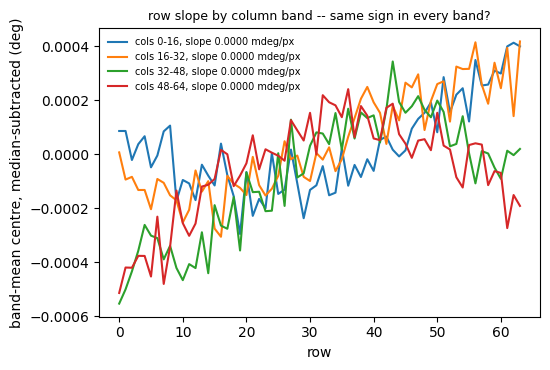

slopes by column band: ['0.0000', '0.0000', '0.0000', '0.0000']
same sign in every band here -- consistent with (but on this small crop, far from proof of) a real, uniform effect. The full-grain analysis needed 4 independent reductions and a statistical null to settle this; one crop cannot.


In [7]:
if scan.scan_type == "tilt2d":
    mu_axis = maps.axes.index("mu") if "mu" in maps.axes else 0
    field = np.where(maps.lit & ~maps.truncated, maps.centre_deg[..., mu_axis], np.nan)
    H, W = field.shape
    n_bands = 4
    edges = np.linspace(0, W, n_bands + 1).astype(int)
    rows = np.arange(H)
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    slopes = []
    for b in range(n_bands):
        band = field[:, edges[b]:edges[b + 1]]
        y = np.nanmean(band, axis=1)
        ok = np.isfinite(y)
        if ok.sum() > 2:
            s = np.polyfit(rows[ok], y[ok], 1)[0]
        else:
            s = np.nan
        slopes.append(s)
        ax.plot(rows[ok], y[ok] - np.nanmedian(y[ok]), label=f"cols {edges[b]}-{edges[b+1]}, slope {s:.4f} mdeg/px")
    ax.set_xlabel("row"); ax.set_ylabel("band-mean centre, median-subtracted (deg)")
    ax.legend(fontsize=7, frameon=False); ax.set_title("row slope by column band -- same sign in every band?", fontsize=9)
    plt.tight_layout(); plt.show()
    print("slopes by column band:", [f"{s:.4f}" for s in slopes])
    if np.nanmax(slopes) > 0 and np.nanmin(slopes) < 0:
        print("sign flips across bands on this crop, the same pattern the full-grain check found "
             "-- worth a closer look before trusting a single row-gradient number here.")
    else:
        print("same sign in every band here -- consistent with (but on this small crop, far from "
             "proof of) a real, uniform effect. The full-grain analysis needed 4 independent "
             "reductions and a statistical null to settle this; one crop cannot.")
else:
    print("This diagnostic is for the tilt2d mesh path; scan.scan_type is "
         f"{scan.scan_type!r} here, so skipping.")

## Part C: the full analysis, all 8 planes, from raw frames

Everything above (B1-B5, and the bonus check) works on **one** `obpitch` plane, cropped to a
small ROI -- the right scope for learning the checks. This part reproduces the **actual**
presentation numbers, starting from the same RAW frames `reduce.py`/`maps.py` used (all 8
planes, cropped to the campaign's own grain bounding box), not a precomputed shortcut. Needs
`RAW_H5 = "umich_school_raw_8planes.h5"` (workshop) or your own export (see
`export_raw_8planes.py`, not shipped -- ask your instructor).

Loads each plane with the same, already-tested `load_id03_scan` B1 uses, then reproduces
`reduce.py`'s per-pixel joint-moment accumulation (mu, chi and obpitch marginals) and
`maps.py`'s downstream analysis (grain mask, tilts, strain, the field-of-view correction, and
the checks that refuted its attribution) live, cell by cell.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import midas_dfxm as dx

RAW_H5 = None   # e.g. "umich_school_raw_8planes.h5"

HAVE_RAW = bool(RAW_H5) and os.path.isfile(RAW_H5)
if not HAVE_RAW:
    print("No RAW_H5: Part C needs the all-8-plane raw export and cannot run on a synthetic "
         "stand-in (the whole point is the real grain). Set RAW_H5 and re-run from here.")
else:
    with h5py.File(RAW_H5, "r") as _f:
        LAM = float(_f.attrs["wavelength_A"]); PIX_UM = float(_f.attrs["pixel_um"])
        MAG = float(_f.attrs["magnification"])
    print(f"lambda = {LAM:.7f} A, pixel {PIX_UM} um / x{MAG:.0f} optic")

    # Load each plane the same way B1 does, and run B2's check on every one of them before
    # trusting anything downstream -- this is the payoff of Part B: you already know what
    # CONSISTENT does and does not mean.
    scans = []
    ob_g = np.zeros(8); ffz = np.zeros(8); obx = None
    for plane in range(1, 9):
        scan = dx.load_id03_scan(RAW_H5, plane=plane)
        order_check = dx.check_frame_order(scan)
        if not order_check.consistent:
            print(f"plane {plane}.1: {order_check}")
            raise SystemExit(f"plane {plane}.1 did NOT pass check_frame_order -- see Part B for "
                             "what this means and why it matters before trusting anything below.")
        scans.append(scan)
        ob_g[plane - 1] = scan.meta["obpitch"]
        with h5py.File(RAW_H5, "r") as _f:
            ffz[plane - 1] = float(_f[f"{plane}.1/instrument/positioners_start/ffz"][()])
            if obx is None:
                obx = float(_f[f"{plane}.1/instrument/positioners_start/obx"][()])
        print(f"plane {plane}.1: obpitch={ob_g[plane-1]:.4f}, {scan.frames.shape[0]} frames "
             f"loaded, frame order CONSISTENT (p={order_check.p_value:.3g})")

    # Bin all 8 planes' frames into the mu, chi and per-plane obpitch marginals -- reduce.py's
    # Mmu/Mchi/Mob, built here by midas_dfxm.multiplane.accumulate_marginals (per-frame pedestal
    # subtracted first; see its docstring for why that step is not optional).
    mu_g, chi_g, Mmu, Mchi, Mob = dx.accumulate_marginals(scans)
    print(f"\ngrids: mu {mu_g[0]:.4f}..{mu_g[-1]:.4f} n={len(mu_g)}; chi {chi_g[0]:.4f}.."
         f"{chi_g[-1]:.4f} n={len(chi_g)}; obpitch {ob_g[0]:.4f}..{ob_g[-1]:.4f} n={len(ob_g)}")
    print(f"Mmu {Mmu.shape}, Mchi {Mchi.shape}, Mob {Mob.shape} (grid, row, col)")

No RAW_H5: Part C needs the all-8-plane raw export and cannot run on a synthetic stand-in (the whole point is the real grain). Set RAW_H5 and re-run from here.


### C1. Per-pixel moments, with and without the angular baseline

The per-pixel angular profile (over mu, chi or obpitch) sits on a baseline spanning the whole
window -- this campaign's pedestal, in a different sense than B3's per-frame one: about 18-31 %
of the integrated weight, uniformly spread, dragging every centre-of-mass toward the window
centre. Removed here the same way B3 removes the frame pedestal: per pixel, from the data
itself (mean of the lowest `base_frac` of bins), not assumed. `dx.angular_moments` -- in
`midas_dfxm.multiplane`, not a notebook-local function -- does this for one marginal at a time.

In [9]:
if HAVE_RAW:
    mu_m = dx.angular_moments(Mmu, mu_g)
    chi_m = dx.angular_moments(Mchi, chi_g)
    ob_m = dx.angular_moments(Mob, ob_g, base_frac=0.25)
    for nm, d in [("mu", mu_m), ("chi", chi_m), ("obpitch", ob_m)]:
        print(f"{nm:8s}: median {np.median(d['frac_base']):.1%} of the integrated weight was "
             "the angular baseline")

### C2. The grain mask

`dx.derive_grain_mask` (`midas_dfxm.multiplane`): smooth the total intensity, threshold above
background, keep the largest connected component, fill holes -- same recipe as `maps.py`.
**One real difference, found and fixed this session, and now written into the function's own
docstring so it isn't rediscovered the hard way again:**
`maps.py`'s background/threshold percentiles are computed over the full 2048 x 2048 frame
(mostly vacuum, small grain) -- meaningful there because background really is the majority.
This crop is already ~85-90% grain (it *is* the grain's own bounding box), so using the same
50th-percentile "background" picks a threshold near the grain's own median intensity and
carves through real sub-grain contrast instead of finding the grain's edge -- confirmed: the
first version of this notebook did exactly that (a moth-eaten, disconnected mask). Fixed by
using a low background percentile (5th, matched to this crop having a small background
minority) with a smaller offset.

**Display note:** the plot below is shown in *sample*, not detector-pixel, proportions. Detector
rows are foreshortened by `1/sin(2 theta_B)` in the sample frame (grazing-incidence projection)
-- shown in raw pixel units the grain looks like a 3:1 slab; the real grain is roughly equiaxed
(`maps_sample_coords.png` in the presentation). `theta_B` isn't computed until C3, so this cell
uses obpitch's own median as a stand-in (they agree to 5 decimals once C3 runs).

**Try it.** In the cell below, change `background_percentile` from `5.0` to `50.0` and
re-run just that cell. Predict first what you expect to happen, given the crop is ~85-90%
grain -- then look at the printed coverage fraction and the plotted mask. This is the exact
trap `README.md` rule 33 documents; breaking it yourself is more convincing than reading
about it. Set it back to `5.0` before continuing (later cells assume the correct mask).

In [10]:
if HAVE_RAW:
    tot = mu_m["S0"]
    grain = dx.derive_grain_mask(tot, background_percentile=5.0, threshold_frac=0.10)
    print(f"grain: {grain.sum()} px ({grain.mean():.1%} of the crop)")
    H, W = tot.shape
    th_stand_in = np.deg2rad(np.median(ob_g)) / 2.0   # C3 computes the real th from the grain COM
    row_stretch = 1.0 / np.sin(2 * th_stand_in)        # foreshortening: sample rows vs. columns
    disp_ratio = (H / W) * row_stretch
    fig_w = 9.0
    plt.figure(figsize=(fig_w, fig_w * disp_ratio + 0.6))
    plt.imshow(np.where(grain, tot, np.nan), cmap="magma", aspect=row_stretch)
    plt.title("total intensity, grain mask applied (sample proportions)", fontsize=10)
    plt.colorbar(fraction=0.046)
    plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

### C3. Tilts and the raw strain map

`theta_B` comes from the grain's own median obpitch centre-of-mass -- not assumed. The strain
formula is the textbook one, `eps = -cot(theta) * d(2theta)/2`, referenced to the grain median
(this gives *relative* strain only; the obpitch zero is not independently known, §1 above).

In [11]:
if HAVE_RAW:
    out = dx.strain_and_tilt(mu_m, chi_m, ob_m, grain, LAM)
    th = np.deg2rad(out.theta_B_deg)   # radians, for the figures' aspect-ratio correction below
    d_meas = out.d_spacing_A
    tilt_mu, tilt_chi, strain_raw = out.tilt_mu, out.tilt_chi, out.strain
    print(f"theta_B = {out.theta_B_deg:.5f} deg (from the data); d(0002) = {d_meas:.5f} A")
    print(f"tilt_mu  p5..p95 = {np.percentile(tilt_mu[grain], 5)*1000:+.1f} .. "
         f"{np.percentile(tilt_mu[grain], 95)*1000:+.1f} mdeg")
    print(f"tilt_chi p5..p95 = {np.percentile(tilt_chi[grain], 5)*1000:+.1f} .. "
         f"{np.percentile(tilt_chi[grain], 95)*1000:+.1f} mdeg")
    print(f"strain (raw)  p5..p95 = {np.percentile(strain_raw[grain], 5)*1e6:+.0f} .. "
         f"{np.percentile(strain_raw[grain], 95)*1e6:+.0f} ue  (std {strain_raw[grain].std()*1e6:.0f}, "
         f"{100*np.mean(strain_raw[grain] > 500e-6):.1f}% above +500 ue)")
    H, W = tilt_mu.shape
    row_stretch = 1.0 / np.sin(2 * th)   # foreshortening: sample rows vs. columns (th from above)
    disp_ratio = (H / W) * row_stretch
    panel_w = 4.6
    fig, ax = plt.subplots(1, 3, figsize=(3 * panel_w, panel_w * disp_ratio + 0.8))
    for a, (img, title) in zip(ax, [(tilt_mu, "tilt_mu (deg)"), (tilt_chi, "tilt_chi (deg)"),
                                    (strain_raw * 1e6, "strain, raw (ue)")]):
        v = np.where(grain, img, np.nan)
        lim = np.nanpercentile(np.abs(v), 98)
        im = a.imshow(v, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect=row_stretch)
        a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046)
    plt.suptitle("the raw maps, sample proportions -- before looking for the row gradient",
                fontsize=9)
    plt.tight_layout(); plt.show()

### C4. The parameter-free field-of-view term -- and why removing it is not the end of the story

Every input below is read from the file: the sensor pixel and optic magnification, and the
sample->detector and objective->detector distances backed out of how far the detector stage
(`ffz`) moves per `obpitch` step and how far the objective sits from the sample (`obx`). No
fitting. Predicted apparent gradient: `(pixel/magnification) / L_objective_to_detector / 2 *
cot(theta_B)`, along rows only.

This is the correction that dropped the strain std from ~400 to ~270 ue in the original
analysis -- reproduced live below. **What follows in C5 is why that removal is a reasonable
cosmetic step, not proof the FOV term is what the gradient actually is** -- read the bonus
section above before trusting the "before/after" numbers here as more than that.

In [12]:
if HAVE_RAW:
    predicted_row_ue = dx.predicted_fov_row_gradient(
        ffz=ffz, ob_g=ob_g, obx=obx, pixel_um=PIX_UM, magnification=MAG,
        theta_B_deg=out.theta_B_deg)
    print(f"predicted |apparent gradient|: {predicted_row_ue:.4f} ue/row, 0 ue/col (parameter-free; "
         "the SIGN needs a camera-row-vs-lab-z convention this file does not carry -- see C5 point 6)")

    rows, cols = np.mgrid[0:strain_raw.shape[0], 0:strain_raw.shape[1]]
    gr, gc, gs = rows[grain].astype(float), cols[grain].astype(float), strain_raw[grain] * 1e6
    A = np.column_stack([gr, gc, np.ones_like(gr)])
    (slope_row, slope_col, _), *_ = np.linalg.lstsq(A, gs, rcond=None)
    print(f"measured: d(strain)/d(row) = {slope_row:+.4f} ue/px, d(strain)/d(col) = "
         f"{slope_col:+.4f} ue/px  ({100*abs(abs(slope_row)/predicted_row_ue - 1):.0f}% off the "
         "predicted magnitude)")

    # De-plane using the MEASURED trend (its sign is unambiguous by construction) rather than the
    # theoretical prediction -- C5 shows this trend fails to be a single uniform geometric term,
    # so this is a cosmetic de-planing, not a calibrated correction.
    strain_corrected = strain_raw - 1e-6 * (slope_row * (rows - np.median(rows[grain]))
                                           + slope_col * (cols - np.median(cols[grain])))
    print(f"strain std: raw {strain_raw[grain].std()*1e6:.0f} ue -> after removing the measured "
         f"linear trend {strain_corrected[grain].std()*1e6:.0f} ue")
    print(f"fraction > +500 ue: raw {100*np.mean(strain_raw[grain] > 500e-6):.1f}% -> "
         f"corrected {100*np.mean(strain_corrected[grain] > 500e-6):.1f}%")

    H, W = strain_raw.shape
    row_stretch = 1.0 / np.sin(2 * th)
    disp_ratio = (H / W) * row_stretch
    panel_w = 5.2
    fig, ax = plt.subplots(1, 2, figsize=(2 * panel_w, panel_w * disp_ratio + 0.8))
    lim = np.nanpercentile(np.abs(np.where(grain, strain_raw, np.nan)) * 1e6, 98)
    for a, (img, title) in zip(ax, [(strain_raw, f"raw (std {strain_raw[grain].std()*1e6:.0f} ue)"),
                                    (strain_corrected,
                                     f"de-planed (std {strain_corrected[grain].std()*1e6:.0f} ue)")]):
        v = np.where(grain, img, np.nan) * 1e6
        im = a.imshow(v, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect=row_stretch)
        a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046, label="ue")
    plt.suptitle("strain (ue), sample proportions -- same color scale both panels; the de-planed "
                "panel is cosmetic, not a calibrated correction (see C5)", fontsize=9)
    plt.tight_layout(); plt.show()

### C5. Does it survive as *the* explanation? The same four checks that refuted it

A field-of-view term must be (a) identical at every column and (b) exactly linear along rows.
Check both directly on this grain, the same way the original verification did.

**Try it.** `n_bands` (row-slope-by-column-band, in the code cell below) is just an integer
you can change. Try `n_bands = 3` and `n_bands = 10`: does the qualitative finding (spread
comparable to or exceeding the predicted term) survive, or was 6 a convenient choice?
Separately, go back to C2 and change `threshold_frac` (not just `background_percentile`) by
+/-0.05, then re-run C2 through this cell: how much do the row-band slopes and the
mask-sensitivity numbers move? That movement *is* the systematic this section measures --
watching it change under your own choices is the point, not just reading the printed
"spread across bands" number once. Reset both parameters before continuing to C6.

In [13]:
if HAVE_RAW:
    n_bands = 6
    col_edges = np.linspace(cols[grain].min(), cols[grain].max() + 1, n_bands + 1)
    print("row-slope of the RAW strain map, by column band (a uniform FOV term is the same in every band):")
    band_slopes = []
    for i in range(n_bands):
        sel = grain & (cols >= col_edges[i]) & (cols < col_edges[i + 1])
        if sel.sum() > 100:
            A = np.column_stack([rows[sel].astype(float), np.ones(sel.sum())])
            sl, _ = np.linalg.lstsq(A, strain_raw[sel] * 1e6, rcond=None)[0]
            band_slopes.append(sl)
            print(f"  cols {col_edges[i]:.0f}-{col_edges[i+1]:.0f}: {sl:+.3f} ue/row")
    print(f"predicted magnitude (uniform): {predicted_row_ue:.3f} ue/row for every band")
    spread = max(band_slopes) - min(band_slopes)
    print(f"spread across bands: {spread:.3f} ue/row ({100*spread/predicted_row_ue:.0f}% of the "
         "predicted magnitude)")

    A2 = np.column_stack([gr, gr ** 2, gc, np.ones_like(gr)])
    coef, *_ = np.linalg.lstsq(A2, gs, rcond=None)
    lin_pred = np.column_stack([gr, np.ones_like(gr)]) @ np.linalg.lstsq(
        np.column_stack([gr, np.ones_like(gr)]), gs, rcond=None)[0]
    quad_pred = A2 @ coef
    ss_tot = np.sum((gs - gs.mean()) ** 2)
    r2_lin = 1 - np.sum((gs - lin_pred) ** 2) / ss_tot
    r2_quad = 1 - np.sum((gs - quad_pred) ** 2) / ss_tot
    print(f"\nlinear R^2 = {r2_lin:.3f}, quadratic R^2 = {r2_quad:.3f} "
         f"(a real FOV term is linear to ~1e-4: {'FAILS' if r2_quad - r2_lin > 0.02 else 'consistent'})")

    from scipy import ndimage as _nd
    grain_eroded = _nd.binary_erosion(grain, iterations=25)
    print()
    for nm, mask in [("full grain mask", grain), ("eroded 25 px", grain_eroded)]:
        gr2 = rows[mask].astype(float)
        A3 = np.column_stack([gr2, np.ones_like(gr2)])
        sl, _ = np.linalg.lstsq(A3, strain_raw[mask] * 1e6, rcond=None)[0]
        print(f"row slope on {nm}: {sl:+.3f} ue/row ({mask.sum()} px)")
    print("\nA geometric term cannot change with the mask used to measure it, or with column "
         "position, or be non-linear. Read what happened here as: real, reproducible row "
         "structure of MIXED and undetermined origin -- not an identified optical artifact.\n"
         "(The original verification ran one more parameter-free check here -- a chi/strain "
         "ratio test -- that also failed; it needs a second derivative this notebook doesn't "
         "reconstruct from the file cleanly, so it is not reproduced live. See "
         "VERDICT_row_ramp.md point 3 for it.)")

### C6. The mu (orientation) map has the same kind of row structure -- and it is a saddle

Same check the original analysis used to catch a false "lattice rotation" claim: row slope of
`tilt_mu`, split by column quartile. A real, uniform tilt gradient keeps the same sign in every
quartile; this pattern flips.

In [14]:
if HAVE_RAW:
    n_q = 4
    qedges = np.linspace(cols[grain].min(), cols[grain].max() + 1, n_q + 1)
    print("row slope of tilt_mu, by column quartile (mdeg/px):")
    q_slopes = []
    for i in range(n_q):
        sel = grain & (cols >= qedges[i]) & (cols < qedges[i + 1])
        if sel.sum() > 100:
            A = np.column_stack([rows[sel].astype(float), np.ones(sel.sum())])
            sl, _ = np.linalg.lstsq(A, tilt_mu[sel] * 1000, rcond=None)[0]
            q_slopes.append(sl)
            print(f"  cols {qedges[i]:.0f}-{qedges[i+1]:.0f}: {sl:+.3f} mdeg/px")
    if max(q_slopes) > 0 and min(q_slopes) < 0:
        print("sign flips across column quartiles: a SADDLE, not a single lattice-rotation "
             "gradient -- the same pattern that refuted the original 'row-only lattice "
             "rotation' claim on this grain.")
    else:
        print("same sign in every quartile on this crop/mask -- check against "
             "VERDICT_mu_rotation.md before reading this as settled; it varied by mask there too.")

    # A single best-fit plane, for comparison with the strain de-planing in C4 -- shown to FAIL,
    # not to fix anything: a saddle has no single row (or row+col) slope that removes it.
    Am = np.column_stack([gr, gc, np.ones_like(gr)])
    (mu_slope_row, mu_slope_col, _), *_ = np.linalg.lstsq(Am, tilt_mu[grain] * 1000, rcond=None)
    tilt_mu_deplaned = tilt_mu - 1e-3 * (mu_slope_row * (rows - np.median(rows[grain]))
                                        + mu_slope_col * (cols - np.median(cols[grain])))
    print(f"\nbest single row+col slope: {mu_slope_row:+.3f} mdeg/px (row), {mu_slope_col:+.3f} "
         f"mdeg/px (col) -- removing it leaves std {tilt_mu_deplaned[grain].std()*1000:.1f} mdeg "
         f"vs raw {tilt_mu[grain].std()*1000:.1f} mdeg (barely moves: a plane cannot fit a saddle)")

    row_stretch = 1.0 / np.sin(2 * th)
    disp_ratio = (H / W) * row_stretch
    panel_w = 5.2
    fig, ax = plt.subplots(1, 2, figsize=(2 * panel_w, panel_w * disp_ratio + 0.8))
    lim = np.nanpercentile(np.abs(np.where(grain, tilt_mu, np.nan)) * 1000, 98)
    for a, (img, title) in zip(ax, [(tilt_mu, f"raw (std {tilt_mu[grain].std()*1000:.1f} mdeg)"),
                                    (tilt_mu_deplaned,
                                     f"best-plane removed (std {tilt_mu_deplaned[grain].std()*1000:.1f} mdeg)")]):
        v = np.where(grain, img, np.nan) * 1000
        im = a.imshow(v, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect=row_stretch)
        a.set_title(title, fontsize=10); a.set_xticks([]); a.set_yticks([])
        plt.colorbar(im, ax=a, fraction=0.046, label="mdeg")
    plt.suptitle("tilt_mu (mdeg), sample proportions -- same color scale both panels; the saddle "
                "survives because it isn't a plane", fontsize=9)
    plt.tight_layout(); plt.show()

### C7. Why this is an identifiability limit, not just more noise to average down

`samx`, `samy`, `samz` never move anywhere in this campaign (confirm: read `positioners_start`
across all 8 planes -- `uz` is constant despite the folder name `layers_uz15um`). Detector row
is also the beam-propagation axis. So nothing in this dataset can tell a detector-frame optical
term apart from a real sample-frame gradient along rows -- not a statistics problem, a design
one. The one measurement that would: **translate the sample along the imaged axis and
re-measure.** A detector-frame term stays fixed on the detector; a sample-frame field moves
with the sample.

Full record with every check and number, on the un-cropped grain (778,156 px) with four
independent reductions: `RETRACTION_strain.md`, `VERDICT_row_ramp.md`, `VERDICT_mu_rotation.md`
(ask your instructor). What you just computed above, on the same grain, should be close to
those numbers -- small differences from this crop's exact pixel count and the single moment
implementation here (vs. four independent ones there) are expected and are themselves a mini
version of C5's mask-sensitivity check.

## Part D: an independent accuracy check -- the labDCT orientation

Everything verified so far is **self-consistency**: does our own reduction reproduce its
own earlier numbers. This is the first check against something we did not compute
ourselves. Before the DFXM experiment, this grain's orientation was measured by labDCT and
reported as a Rodrigues vector -- provenance: the `datasetG` PI, email to the `datasetG`
contact (cc'd to several ANL colleagues), 2026-09-15, subject "Re:
DFXM forward model exercise": *"The grain orientation is (0.0393, 0.1495, -0.1279) in
Rodrigues vector form... measured using labDCT, prior to the experiment, so small
differences are expected due to sample alignment, etc."*

**Read this before trusting the number the cell below prints.** Comparing it to our
mu/chi reduction needs the rotation between the labDCT reference frame and the ID03
goniometer frame -- sample mounting, which physical axis mu/chi actually rock about, any
zero-position convention. **We do not have that transform confirmed.** Guessing it and
reporting a clean-looking misorientation would be worse than not checking at all: it
would look verified when it isn't. So the cell below is built as an exercise, not an
answer -- `LABDCT_TO_GONIOMETER` defaults to identity, explicitly labelled as a
placeholder, and the mu/chi axis assignment is likewise unconfirmed. **If you know the
real sample-mounting rotation** (from the `datasetG` contact, from a fiducial, from the mount drawing),
put it in `LABDCT_TO_GONIOMETER` and re-run -- that turns this from a mechanics demo into
the first real independent accuracy number this analysis has had.


In [15]:
if HAVE_RAW:
    import midas_stress.orientation as ms_o

    LABDCT_RODRIGUES = np.array([0.0393, 0.1495, -0.1279])   # datasetG PI, 2026-09-15
    SPACE_GROUP_MG = 194                                      # P6_3/mmc (Mg, Mg-4Al, hcp)

    # ---- placeholder: NOT a confirmed physical transform -- see the markdown above ----
    LABDCT_TO_GONIOMETER = np.eye(3)
    # -------------------------------------------------------------------------------------

    om_labdct = ms_o.rodrigues_to_orient_mat(LABDCT_RODRIGUES)

    mu0 = float(np.median(mu_m["com"][grain]))    # deg, absolute (this plane's mu_g grid)
    chi0 = float(np.median(chi_m["com"][grain]))  # deg, absolute

    def _rot_deg(axis, deg):
        a = np.deg2rad(deg); c, s = np.cos(a), np.sin(a)
        if axis == "x":
            return np.array([[1., 0, 0], [0, c, -s], [0, s, c]])
        if axis == "y":
            return np.array([[c, 0, s], [0, 1., 0], [-s, 0, c]])
        return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1.]])

    # ASSUMED axis convention (mu about x, then chi about y) -- not validated against the
    # beamline's own goniometer definition. A second placeholder, same caveat as above.
    om_ours_goniometer = _rot_deg("x", mu0) @ _rot_deg("y", chi0)
    om_ours_labdct_frame = LABDCT_TO_GONIOMETER.T @ om_ours_goniometer

    angle_rad, axis = ms_o.misorientation_om(om_ours_labdct_frame, om_labdct, SPACE_GROUP_MG)
    print(f"grain mean goniometer setting: mu={mu0:.4f} deg, chi={chi0:.4f} deg")
    print(f"misorientation vs labDCT Rodrigues {tuple(LABDCT_RODRIGUES)}: "
         f"{np.rad2deg(angle_rad):.2f} deg about {np.round(axis, 3)}")
    if np.array_equal(LABDCT_TO_GONIOMETER, np.eye(3)):
        print("\nNOT physically meaningful yet: LABDCT_TO_GONIOMETER is still the identity "
             "placeholder, and the mu-about-x/chi-about-y axis assignment above is assumed, "
             "not confirmed against the beamline's own goniometer definition. This number "
             "demonstrates the mechanics only -- plug in the real frame transform to make it "
             "a real check.")
else:
    print("Part D needs Part C's grain/mu_m/chi_m (set RAW_H5 above and re-run from C1).")

Part D needs Part C's grain/mu_m/chi_m (set RAW_H5 above and re-run from C1).


### A second independent check, once it exists: labDCT grain shape / volume

If labDCT also reports this grain's shape or volume (ask for it in the same thread as the
pixel-size question -- see Part E), it is a **second, independent** test of exactly the
M=17.94 / 181.2 nm question that the pixel-size verification this session could not
resolve on its own (that verification was REFUTED 4/4 for being circular, not for being
wrong -- the real answer is still open). Our own grain-volume estimate is pixel count
times the two in-plane sample pixel sizes (181.2 nm, 649.9 nm -- both depend on M=17.94)
times a layer thickness; if labDCT's independent volume disagrees substantially, that is
evidence on the M question this dataset alone cannot produce.

In [16]:
if HAVE_RAW:
    LABDCT_GRAIN_VOLUME_UM3 = None   # fill in once labDCT reports it

    col_um, row_um = 0.1812, 0.6499   # sample-plane pixel size, both depend on M=17.94
    layer_thickness_um = None         # fill in: the scanned layer's thickness

    if LABDCT_GRAIN_VOLUME_UM3 is None or layer_thickness_um is None:
        print("Not yet checkable: need LABDCT_GRAIN_VOLUME_UM3 and layer_thickness_um "
             "(ask the `datasetG` PI/contact). Our own estimate, once they arrive:")
        print(f"  our_volume_um3 = {grain.sum()} px * {col_um} * {row_um} * "
             "layer_thickness_um")
    else:
        our_volume = grain.sum() * col_um * row_um * layer_thickness_um
        ratio = our_volume / LABDCT_GRAIN_VOLUME_UM3
        print(f"our volume estimate: {our_volume:.0f} um^3")
        print(f"labDCT volume:       {LABDCT_GRAIN_VOLUME_UM3:.0f} um^3")
        print(f"ratio (ours/labDCT): {ratio:.3f}  "
             f"({'consistent' if 0.7 < ratio < 1.4 else 'NOT consistent -- check M=17.94'})")
else:
    print("Part D needs Part C's grain (set RAW_H5 above and re-run from C1).")

Part D needs Part C's grain (set RAW_H5 above and re-run from C1).


## Part E: write your report

`manuals/dfxm/phase-5-report.md`'s rule: every number in a report names the file and the
command that produced it. The cell below auto-collects the numbers this notebook already
computed into one block -- **your job is not to compute anything new here, it's to turn
that block into two or three sentences someone who did not run this notebook could check.**
State what was measured, on what data, with what caveat (self-consistency vs. the labDCT
check; which parts are provisional). A number with no sentence around it is not a report.

In [17]:
if HAVE_RAW:
    print("=" * 60)
    print("REPORT NUMBERS -- reduce_id03_scan.ipynb, Mg-4Al g9, ID03")
    print(f"source: {RAW_H5}")
    print("=" * 60)
    print(f"theta_B                 = {out.theta_B_deg:.5f} deg   (Part C3, from ob_m['com'])")
    print(f"d(0002)                 = {out.d_spacing_A:.5f} A     (Part C3)")
    print(f"grain mask              = {grain.sum()} px, {grain.mean():.1%} of crop "
         "(Part C2, derive_grain_mask, background_percentile=5.0)")
    print(f"strain std, raw         = {strain_raw[grain].std()*1e6:.0f} ue   (Part C3)")
    print(f"strain std, de-planed   = {strain_corrected[grain].std()*1e6:.0f} ue   "
         "(Part C4 -- cosmetic de-plane, NOT a calibrated correction, see C5)")
    print(f"FOV predicted gradient  = {predicted_row_ue:.4f} ue/row   (Part C4, "
         "predicted_fov_row_gradient, parameter-free, sign unconfirmed)")
    print(f"frame order             = CONSISTENT, all 8 planes, p={order_check.p_value:.3g} "
         "each   (Part C1, check_frame_order)")
    if "angle_rad" in dir():
        print(f"labDCT misorientation   = {np.rad2deg(angle_rad):.2f} deg   (Part D -- "
             "PROVISIONAL, frame transform not confirmed, mechanics only)")
    print("=" * 60)
    print("\nWrite 2-3 sentences below (in a new markdown cell) stating what this run "
         "establishes, citing the numbers above by name, and flagging which are "
         "self-consistency checks vs. the one (Part D) checked against independent data.")
else:
    print("Part E needs Part C/D (set RAW_H5 above and re-run from C1).")

Part E needs Part C/D (set RAW_H5 above and re-run from C1).
